# Token evolution on the energy landscape

In [ ]:
import yaml
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb
import torch

from energy_transformers.model_config import TransformerConfig
from energy_transformers.baseline_transformer import RecursiveCGPT
from energy_transformers.energy_transformer import RecursiveNRGPT

In [ ]:
# Load data
xte = pd.read_parquet("../data/processed/listops32_tk_test_X.parquet")
yte = pd.read_parquet("../data/processed/listops32_tk_test_y.parquet")
with open("../data/processed/listops32_dictionary.json", "r") as f:
    dictionary = yaml.safe_load(f)

In [ ]:
# Load the model
REGISTRY_NAME = "NRGPT"
COLLECTION_NAME = "NRGPT Models"
VERSION = 0

model_art_name = f"wandb-registry-{REGISTRY_NAME}/{COLLECTION_NAME}:v{VERSION}"

In [ ]:
def load_model_from_registry(artifact_path: str, device="cpu", n_layers=0):
    """
    Example artifact_path: "your_entity/listops32_nrgpt_baseTran/model-abcd123:v0"
    """
    api = wandb.Api()

    # 1. Fetch and download the artifact
    print(f"Downloading artifact: {artifact_path}")
    artifact = api.artifact(artifact_path)
    artifact_dir = artifact.download()

    # 2. Extract configurations from the metadata you saved
    model_class_name = artifact.metadata["model_class"]
    model_config_dict = artifact.metadata["model_config"]

    # Optionally, change the number of internal iterations
    if n_layers != 0:
        # Modify the number of layers in ocnfig
        model_config_dict["n_layers"] = n_layers

    # 3. Reconstruct the Model Configuration
    config = TransformerConfig(**model_config_dict)

    # 4. Instantiate the correct model class
    if model_class_name == "RecursiveCGPT":
        model = RecursiveCGPT(config).to(device)
    else:
        model = RecursiveNRGPT(config).to(device)

    # 5. Find the downloaded .pth file and load the weights
    # (Grabs the first .pth file in the downloaded artifact directory)
    weights_file = [f for f in os.listdir(artifact_dir) if f.endswith(".pth")][
        0
    ]
    weights_path = os.path.join(artifact_dir, weights_file)

    # Safely load weights (map_location ensures it works even if downloaded on a CPU-only machine)
    state_dict = torch.load(
        weights_path, map_location=device, weights_only=True
    )

    # Edge Case Fix: Strip 'module.' prefix if it was saved via DataParallel
    clean_state_dict = {
        k.replace("module.", ""): v for k, v in state_dict.items()
    }

    model.load_state_dict(clean_state_dict)
    model.eval()

    print("✅ Model successfully reconstructed and weights loaded!")
    return model


# Usage:
model = load_model_from_registry(model_art_name, device="cpu", n_layers=1)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb:   1 of 1 files downloaded.  


✅ Model successfully reconstructed and weights loaded!


In [ ]:
# Pick a random sample from the test set
np.random.seed(13)  # For reproducibility
sample_idx = np.random.randint(0, len(xte))
x = torch.tensor(xte.iloc[sample_idx].values).unsqueeze(
    0
)  # Add batch dimension
y = torch.tensor(yte.iloc[sample_idx].values).unsqueeze(
    0
)  # Add batch dimension

In [ ]:
def custom_ffwd_energy(model, x):
    fwd_pass = model.blocks.ffwd(x)
    # We need to get per-token energies
    # On original model, set as scalar so grad() works
    energy = -(fwd_pass**2).sum(axis=2)
    return energy


# Iterate through model and manually extract energies
xt = x.to(torch.long)
TOT_ITER = 100
SEQ_LEN = xt.shape[1]
attnenergy_hist = np.zeros((TOT_ITER, SEQ_LEN))
ffwdenergy_hist = np.zeros((TOT_ITER, SEQ_LEN))
with torch.no_grad():
    # We have to pass through token emb + pos enc
    g = model.token_emb(xt) + model.position_emb(xt)
    for i in range(TOT_ITER):
        # Get energy
        g = model.blocks.ln(g)
        eatt = model.blocks.attn.energy(g)
        effwd = custom_ffwd_energy(model, g)

        # Store energies
        attnenergy_hist[i, :] = eatt.squeeze().cpu().numpy()
        ffwdenergy_hist[i, :] = effwd.squeeze().cpu().numpy()

        # Update xt for next iteration
        g = model.block_forward(g)

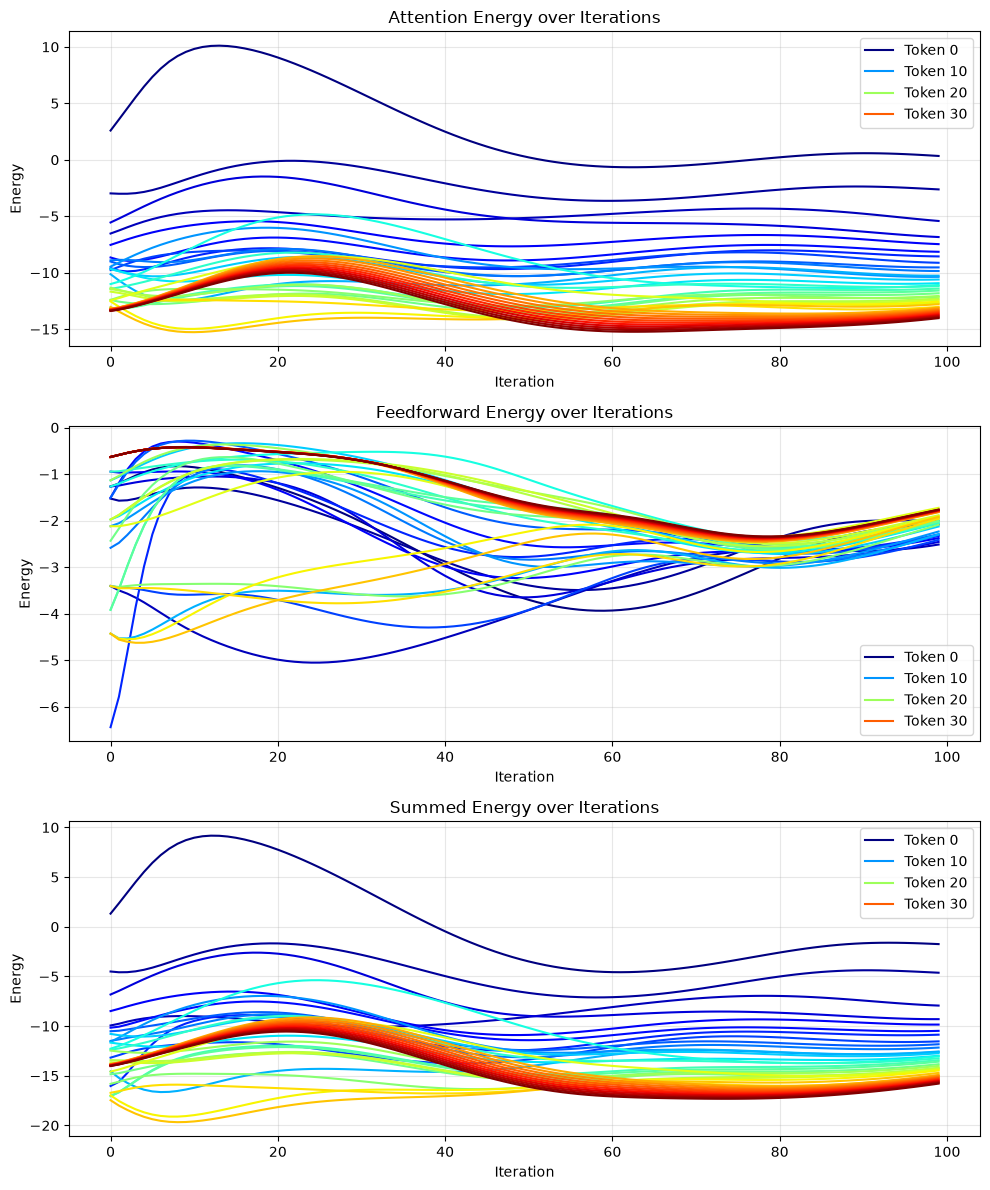

In [ ]:
# Create a colormap (jet: cold colors for low indices, hot colors for high indices)
cmap = plt.cm.jet
norm = plt.Normalize(vmin=0, vmax=SEQ_LEN - 1)

# Prepare legend labels for specific tokens
legend_tokens = [0, 10, 20, 30]

plt.figure(figsize=(10, 12))

# Plot 1: Attention Energy
plt.subplot(3, 1, 1)
for token_idx in range(SEQ_LEN):
    color = cmap(norm(token_idx))
    label = f"Token {token_idx}" if token_idx in legend_tokens else None
    plt.plot(attnenergy_hist[:, token_idx], color=color, label=label)
plt.title("Attention Energy over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Feedforward Energy
plt.subplot(3, 1, 2)
for token_idx in range(SEQ_LEN):
    color = cmap(norm(token_idx))
    label = f"Token {token_idx}" if token_idx in legend_tokens else None
    plt.plot(ffwdenergy_hist[:, token_idx], color=color, label=label)
plt.title("Feedforward Energy over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Summed Energy
plt.subplot(3, 1, 3)
summed_energy_hist = attnenergy_hist + ffwdenergy_hist
for token_idx in range(SEQ_LEN):
    color = cmap(norm(token_idx))
    label = f"Token {token_idx}" if token_idx in legend_tokens else None
    plt.plot(summed_energy_hist[:, token_idx], color=color, label=label)
plt.title("Summed Energy over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()